Proyecto Final – Modelo de Diagnóstico Clínico Multiclase

Este notebook construye un modelo de red neuronal que predice el diagnóstico clínico sin usar la columna de diagnóstico como entrada, evitando fuga de datos.

Incluye:

*   Limpieza de datos
*   Preprocesamiento
*   Entrenamiento del modelo
*   Evaluación clínica


In [ ]:
# ================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from google.colab import files

In [ ]:
# ================================
# 2. CARGA DEL DATASET
# ================================
uploaded = files.upload()

df = pd.read_excel("Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.xlsx")

df.head()

Saving Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.xlsx to Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411 (1).xlsx


,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,RED,IPRESS,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE,...,FEC_RESULTADO_1,DIFERIMIENTO_1,PROCEDIMIENTO_1,RESULTADO_1,UNIDADES_1,FEC_RESULTADO_2,PROCEDIMIENTO_2,RESULTADO_2,UNIDADES_2,DIFERIMIENTO_2
0,20241204,LIMA,LIMA,MIRAFLORES,150122,RED ASISTENCIAL REBAGLIATI,H.III SUAREZ-ANGAMOS,eJwzNDSyNDe0MLcwNjM1NrI0MAAAH10DeQ==,64,FEMENINO,...,20240503,79,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",106.00,mg/dL,20240503,TRIGLICERIDOS,273.0,mg/dL,79
1,20241204,LA LIBERTAD,TRUJILLO,VICTOR LARCO HERRERA,130111,RED ASISTENCIAL LA LIBERTAD,POL. VICTOR LARCO HERRERA,eJwzNrS0NLAwM7YwsjAwNAACAB9eA2s=,9,MASCULINO,...,20240504,70,TRIGLICERIDOS,57.00,mg/dL,20240504,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",84.0,mg/dL,70
2,20241204,CAJAMARCA,JAEN,JAEN,60801,RED ASISTENCIAL JAEN,H.II JAEN,eJwzNDYzNjY3M7A0Njc0MLcwsAQAHyADeg==,47,FEMENINO,...,20240518,82,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",90.83,mg/dL,20240518,TRIGLICERIDOS,54.9,mg/dL,82
3,20241204,LIMA,LIMA,SAN JUAN DE LURIGANCHO,150132,RED ASISTENCIAL ALMENARA,H.I AURELIO DIAZ-UFANO Y PERAL,eJwzNjQ1NjUztLCwNLA0MTE0MAAAH0oDdA==,12,FEMENINO,...,20240518,73,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",83.00,mg/dL,20240518,TRIGLICERIDOS,85.0,mg/dL,73
4,20241204,CALLAO,CALLAO,VENTANILLA,70106,RED ASISTENCIAL SABOGAL,CAP III HNA. MARIA DONROSE SUTMOLLER,eJwzNje0NLMwMjQwNTAwNzQwNwMAHyIDcA==,2,MASCULINO,...,20240513,61,TRIGLICERIDOS,170.00,mg/dL,20240513,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",113.0,mg/dL,61


In [ ]:
# ================================
# 3. LIMPIEZA DEL DATASET
# ================================
df.dropna(inplace=True)

print("Dataset limpio:", df.shape)

Dataset limpio: (63708, 25)


In [ ]:
# ================================
# 4. DEFINICIÓN DE LA VARIABLE OBJETO
# ================================
y = df["Diagnostico_Completo"]

print("Diagnósticos únicos:", y.nunique())

Diagnósticos únicos: 5


In [ ]:
# ================================
# 5. FEATURES SIN FUGA DE DATOS
# ================================
cols_excluir = [
    "COD_DIAG",
    "DIAGNOSTICO",
    "Diagnostico_Completo",
    "Obesidad"
]

X = df.drop(columns=cols_excluir, errors='ignore')

print("Features usadas:", X.shape)

Features usadas: (63708, 21)


In [ ]:
# ================================
# 6. PREPROCESAMIENTO
# ================================
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 11
Categóricas: 10


In [ ]:

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [ ]:
X_processed = preprocessor.fit_transform(X)

print("Features tras encoding:", X_processed.shape)

Features tras encoding: (63708, 650)


In [ ]:
# ================================
# 7. CODIFICACIÓN DE LA VARIABLE OBJETO
# ================================
# Guardamos categorías reales
y_cat_series = y.astype("category")

diagnosticos_reales = y_cat_series.cat.categories

y_codes = y_cat_series.cat.codes
num_classes = len(diagnosticos_reales)

y_cat = to_categorical(y_codes, num_classes)

print("Clases:", num_classes)

Clases: 5


In [ ]:
# ================================
# 8. TRAIN / TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_cat,
    test_size=0.3,
    random_state=42,
    stratify=y_codes
)

In [ ]:
# ================================
# 9. BALANCEO DE CLASES
# ================================
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_codes),
    y=y_codes
)

class_weights = dict(enumerate(weights))

In [ ]:
# ================================
# 10. MODELO NEURONAL
# ================================
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ================================
# 11. ENTRENAMIENTO
# ================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4004 - loss: 1.5114 - val_accuracy: 0.4950 - val_loss: 1.2219
Epoch 2/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5146 - loss: 1.1871 - val_accuracy: 0.5422 - val_loss: 1.1145
Epoch 3/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5391 - loss: 1.0815 - val_accuracy: 0.5508 - val_loss: 1.0750
Epoch 4/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5551 - loss: 1.0335 - val_accuracy: 0.5636 - val_loss: 1.0540
Epoch 5/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5645 - loss: 0.9896 - val_accuracy: 0.5664 - val_loss: 1.0382
Epoch 6/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5743 - loss: 0.9315 - val_accuracy: 0.5607 - val_loss: 1.0521
Epoch 7/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5792 - loss: 0.9117 - val_accuracy: 0.5634 - val_loss: 1.0504
Epoch 8/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5886 - loss: 0.8839 - val_accu

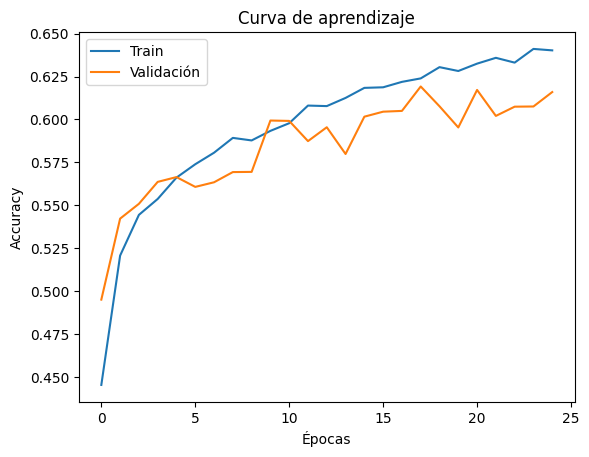

In [ ]:
# ================================
# 12. CURVAS DE APRENDIZAJE
# ================================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Curva de aprendizaje")
plt.ylabel("Accuracy")
plt.xlabel("Épocas")
plt.legend(["Train", "Validación"])
plt.show()

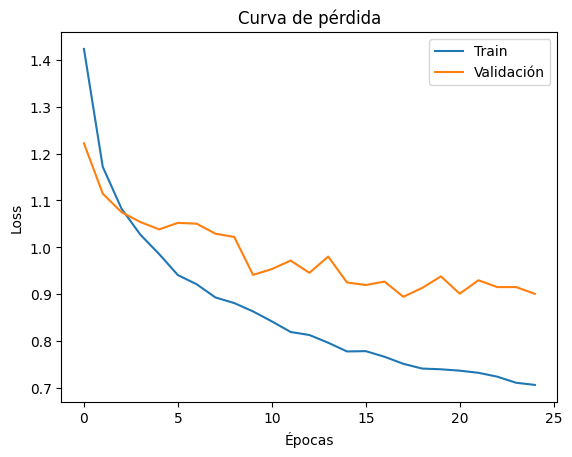

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Curva de pérdida")
plt.ylabel("Loss")
plt.xlabel("Épocas")
plt.legend(["Train", "Validación"])
plt.show()

In [ ]:
# ================================
# 13. EVALUACIÓN FINAL
# ================================
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(true_classes, pred_classes)

print("\nAccuracy final:", acc)

# Convertimos a nombres reales
pred_labels = diagnosticos_reales[pred_classes]
true_labels = diagnosticos_reales[true_classes]

print("\nReporte clínico:\n")
print(classification_report(true_labels, pred_labels))

598/598 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

Accuracy final: 0.6253858630251661

Reporte clínico:

                                      precision    recall  f1-score   support

     Hipotiroidismo, no especificado       0.78      0.75      0.76      7802
Obesidad debida a exceso de calorías       0.52      0.53      0.52      2391
           Obesidad, no especificada       0.63      0.48      0.55      5907
             Otros tipos de obesidad       0.12      0.74      0.20       133
                           Sobrepeso       0.50      0.66      0.57      2880

                            accuracy                           0.63     19113
                           macro avg       0.51      0.63      0.52     19113
                        weighted avg       0.65      0.63      0.63     19113

